In [1]:
from typing import TypedDict
import uuid

from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
import re

In [2]:
class State(TypedDict):
    email: str

In [3]:
def get_valid_email(state: State) -> State:
    prompt = "Please enter a valid email address."

    email_pattern = r"^[\w\.-]+@[\w\.-]+\.\w{2,4}$"

    while True:
        user_input = interrupt(prompt)

        if re.match(email_pattern, user_input):
            break
        else:
            prompt = f"'{user_input}' is not a valid email address. Please enter a valid email."

    return {"email": user_input}

In [4]:
def process_email(state: State) -> State:
    print(f"Email address '{state['email']}' has been accepted and processed.")
    return state

In [5]:
builder = StateGraph(State)
builder.add_node("get_valid_email", get_valid_email)
builder.add_node("process_email", process_email)

builder.set_entry_point("get_valid_email")
builder.add_edge("get_valid_email", "process_email")
builder.add_edge("process_email", END)

checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)

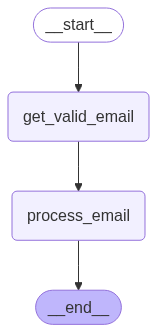

In [6]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
config = {"configurable": {"thread_id": uuid.uuid4()}}
result = graph.invoke({}, config=config)
print(result["__interrupt__"])

[Interrupt(value='Please enter a valid email address.', resumable=True, ns=['get_valid_email:26e975f5-d63b-2e65-335a-48fec494819a'])]


In [8]:
result = graph.invoke(Command(resume="invalid-email"), config=config)
print(result["__interrupt__"])

[Interrupt(value="'invalid-email' is not a valid email address. Please enter a valid email.", resumable=True, ns=['get_valid_email:26e975f5-d63b-2e65-335a-48fec494819a'])]


In [9]:
result = graph.invoke(Command(resume="email@wrong"), config=config)
print(result["__interrupt__"])

[Interrupt(value="'email@wrong' is not a valid email address. Please enter a valid email.", resumable=True, ns=['get_valid_email:26e975f5-d63b-2e65-335a-48fec494819a'])]


In [10]:
final_result = graph.invoke(Command(resume="user@example.com"), config=config)
print(final_result)

Email address 'user@example.com' has been accepted and processed.
{'email': 'user@example.com'}
